<img src="./logo_UNSAM.jpg" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Tarea semanal Nº 8
#### Tatiana Galansky, Guadalupe Cura

### INTRODUCCIÓN TEÓRICA
Un electrocardiograma (ECG) es una señal biológica unidimensional donde la actividad eléctrica del corazón se representa como una función temporal discretizada mediante muestreo. El empleo de algoritmos digitales, en lugar de métodos analógicos, ofrece ventajas notables: permite simular con alta precisión los resultados, facilita el prototipado y brinda gran flexibilidad en el diseño de sistemas.

El propósito central de este trabajo es aplicar metodologías de procesamiento de señales para mitigar las principales fuentes de contaminación presentes en un registro de ECG obtenido durante una prueba de esfuerzo. Dichas interferencias incluyen ruidos de alta frecuencia, típicamente generados por movimiento de electrodos o ruido muscular (electromiográfico), y artefactos de baja frecuencia ocasionados por desplazamientos de la línea de base debidos a la respiración. Para restaurar la señal (buscando una representación suave, estable y con nivel isoeléctrico apropiado) es necesario diseñar un filtro pasa-banda digital que preserve las componentes relevantes del ECG mientras atenúa eficazmente las interferencias externas.

La teoría subyacente al diseño de filtros se basa en la caracterización de los sistemas LTI. Un sistema LTI se describe completamente mediante su respuesta al impulso h[n]. La salida del sistema ante una entrada arbitraria x[n] se obtiene mediante la operación de convolución. En el dominio de la frecuencia, la transformada de Fourier de tiempo discreto (DTFT) permite visualizar la respuesta en magnitud y fase del sistema, simplificando la operación de filtrado a una multiplicación entre las transformadas de entrada y del filtro. Esto proporciona una forma intuitiva de analizar qué componentes espectrales son preservadas o atenuadas.

El diseño de la plantilla del filtro requiere considerar dos arquitecturas fundamentales. Por un lado, los filtros de Respuesta al Impulso Finita (FIR), cuya respuesta al impulso tiene una duración limitada. Un aspecto clave de los FIR es que pueden diseñarse con fase estrictamente lineal, lo cual resulta especialmente importante en señales biomédicas ya que preserva la morfología del ECG sin introducir distorsiones temporales. Para este trabajo se implementarán metodologías basadas en ventanas que aproximan la respuesta ideal mediante truncación controlada, junto con métodos óptimos como la minimización del error cuadrático (least squares).

Por otro lado, los filtros de Respuesta al Impulso Infinita (IIR) permiten alcanzar especificaciones de atenuación más estrictas con un orden significativamente menor. Su diseño se basa típicamente en prototipos analógicos clásicos. En este trabajo se emplearán las aproximaciones de máxima planicidad (Butterworth), que ofrecen una respuesta de magnitud monótona sin ripple, y la aproximación elíptica (Cauer), que proporciona las bandas de transición más estrechas para un orden dado al permitir ripple tanto en la banda de paso como en la de rechazo. La conversión de estos prototipos al dominio digital se realizará mediante la transformación bilineal, método ampliamente utilizado por su adecuado mapeo de frecuencias y estabilidad.

Finalmente, la evaluación del rendimiento de los filtros diseñados consistirá en verificar que la respuesta en frecuencia de cada filtro cumpla la plantilla establecida. Esto implica asegurar una atenuación suficiente en las bandas donde se concentran los artefactos y, simultáneamente, una mínima distorsión en la banda de paso, donde reside la información clínica relevante del ECG.


### ANÁLISIS Y DESARROLLO

En primer lugar, para que la señal de ECG filtrada se asemeje a un latido promedio (con trazos suaves y un nivel isoeléctrico estable) es necesario definir una plantilla de diseño que fije las tolerancias en cada banda del filtro digital.

El análisis de los latidos promedio muestra que el complejo QRS presenta transiciones rápidas cuya duración se encuentra entre 80 y 150 ms según el tipo de latido. Esto implica la presencia de componentes espectrales significativas hasta aproximadamente 30–35 Hz, lo que fundamenta la elección de la banda de paso superior en 35 Hz. Además, los segmentos isoeléctricos observados entre 350 y 500 ms presentan una variación mínima, lo que confirma que las oscilaciones por debajo de 0.5 Hz no pertenecen al contenido fisiológico del ECG y deben eliminarse mediante una banda de rechazo inferior en 0.1–0.5 Hz. Este análisis está fundamentado en la estimación del ancho de banda hallada en la Tarea Semanal 5 (BW=0.3-35.8), donde se analizó una señal ECG limpia utilizando el método de Welch.

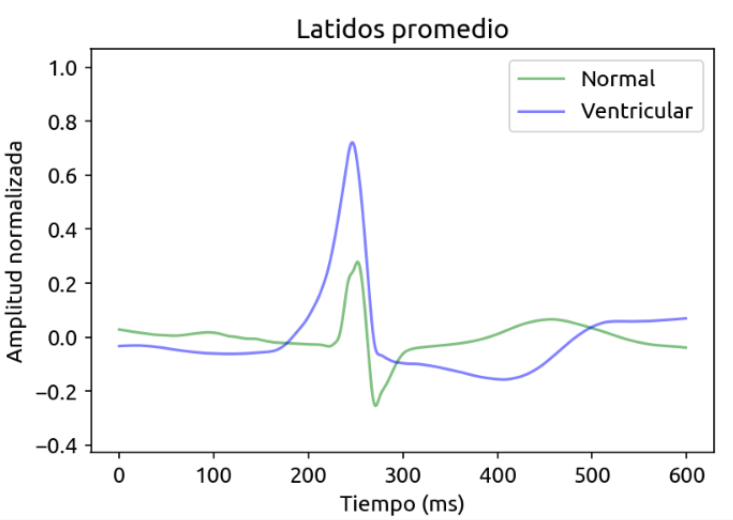

Fuera de ese rango aparecen las principales fuentes de contaminación. Las interferencias de muy baja frecuencia (por ejemplo, el movimiento de la línea de base debido a la respiración o desplazamiento de electrodos) se concentran mayormente por debajo de 0.5 Hz, mientras que el ruido muscular (electromiográfico) y artefactos de movimiento aportan energía por encima de 40 Hz.

En función de estas observaciones, el filtro requerido debe ser pasa-banda, permitiendo el paso del contenido relevante del ECG y atenuando las regiones donde predominan los artefactos. Para ello se establece una banda de paso $\omega_p = [1 Hz, 35.5 Hz]$, dentro de la cual se fija un ripple máximo de 1 dB, garantizando que todas las componentes útiles del ECG sufran una distorsión mínima. Fuera de esa región, es decir por debajo de 0.1 Hz y por encima de 40 Hz, se exige una atenuación de al menos 40 dB, valor suficiente para asegurar la supresión de la mayor parte del ruido de línea de base y del ruido electromiográfico. Por lo tanto, se establece una banda de rechazo $\omega_s = [0.1 Hz, 40 Hz]$. Esta plantilla constituye la referencia fundamental para evaluar posteriormente la respuesta en frecuencia de los distintos filtros FIR e IIR diseñados.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import scipy.io as sio
import matplotlib.patches as patches
from scipy.signal import firwin, firls, freqz
from pytc2.sistemas_lineales import plot_plantilla

# -------------------------
# Parámetros / Plantilla
# -------------------------
fs = 1000
ripple = 1        # dB (pasabanda)
atenuacion = 40   # dB (stopband)

# Plantilla
ws1 = 0.1   # stop baja
wp1 = 1 # inicio pasabanda
wp2 = 35.5    # fin pasabanda
ws2 = 40    # stop alta

# bandas para firls/remez en Hz (NO normalizadas)
bands_full = [0, ws1, wp1, wp2, ws2, fs/2]
deseado = [0, 0, 1, 1, 0, 0]

Una vez establecidos los parámetros, se diseñaron cuatro filtros digitales diferentes, dos pertenecientes a los IIR y dos FIR, con el objetivo de comparar su desempeño frente a la misma plantilla de diseño establecida por las frecuencias de paso, frecuencias de detención y atenuaciones requeridas. Para los diseños IIR se empleó la función iirdesign de SciPy, aplicando dos aproximaciones clásicas: un filtro Butterworth, caracterizado por presentar banda de paso sin ondulación, y un filtro Elíptico (Cauer), que incorpora ondulación tanto en banda de paso como en banda de rechazo a cambio de reducir significativamente el orden necesario.

En paralelo se diseñaron dos filtros FIR utilizando los métodos incluidos en scipy.signal. El primero se generó mediante firwin2, que implementa el método general de ventanas aplicando directamente la magnitud deseada sobre una malla de frecuencias. El segundo se obtuvo usando firls, un diseño por mínimos cuadrados que ajusta la magnitud del filtro buscando minimizar el error cuadrático entre la respuesta obtenida y la deseada. Estos filtros FIR, al ser de fase lineal y no utilizar realimentación, requieren un número de coeficientes considerablemente mayor para satisfacer la misma plantilla que los IIR, pero presentan una respuesta de fase más controlada.

Finalmente, para cada filtro se calcula la respuesta en frecuencia y se compara con la plantilla especificada, permitiendo verificar si cumplen o no con los requisitos impuestos en términos de atenuación y selectividad.


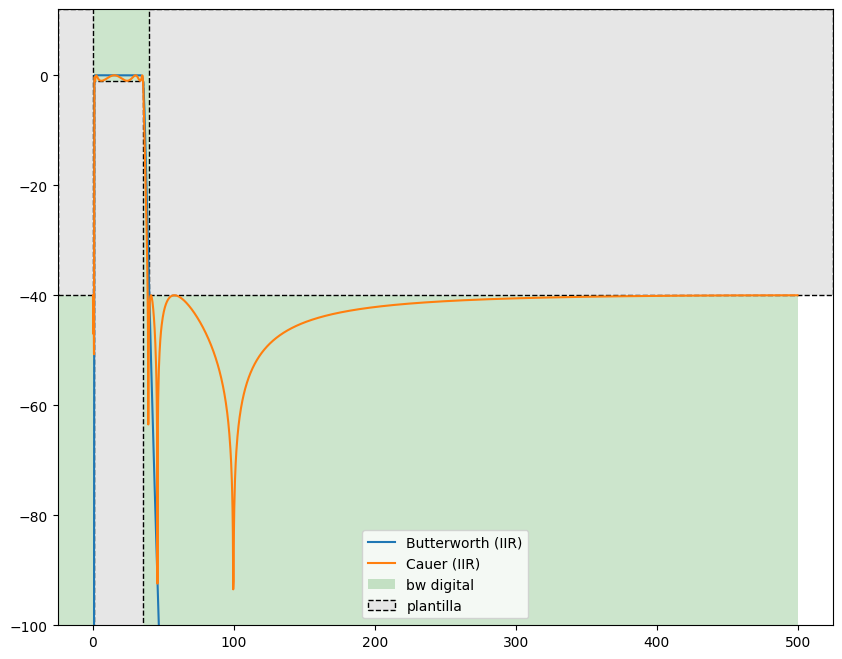

<Figure size 640x480 with 0 Axes>

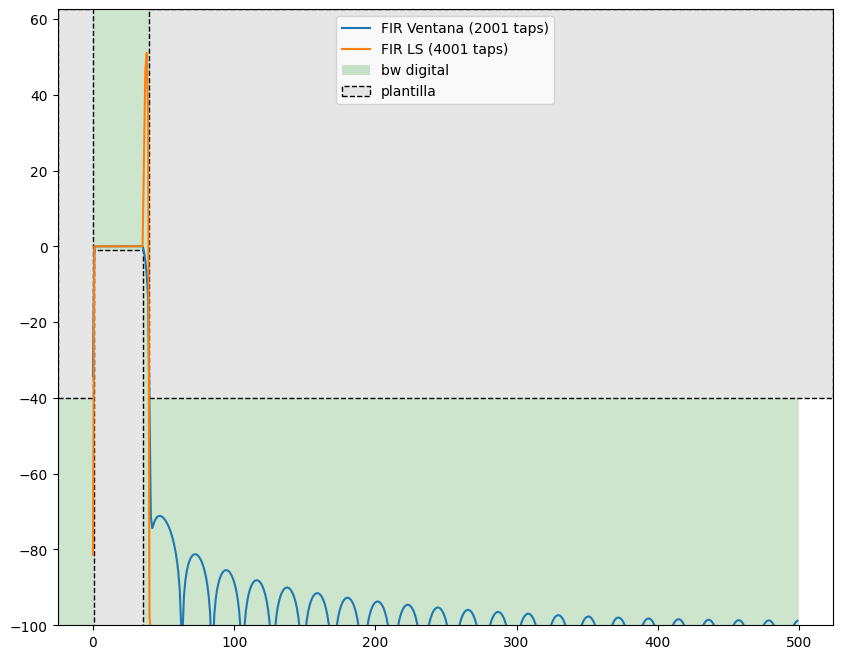

<Figure size 640x480 with 0 Axes>

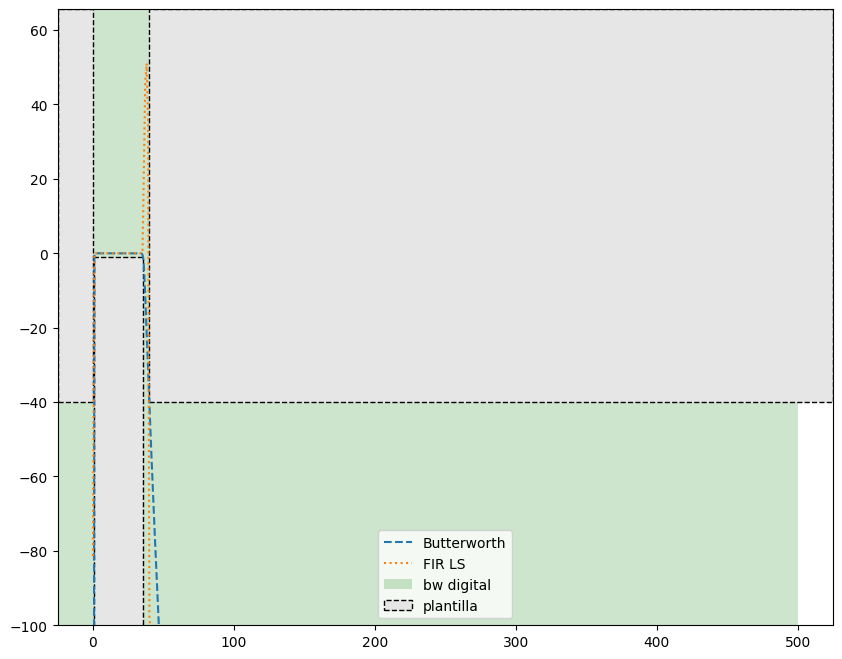

<Figure size 640x480 with 0 Axes>

In [4]:
# -------------------------
# Diseño IIR (sos) - 3 aprox.
# -------------------------
gpass = ripple
gstop = atenuacion
wp = [wp1, wp2]
ws = [ws1, ws2]

sos_butter = signal.iirdesign(wp=wp, ws=ws, gpass=gpass, gstop=gstop,
                              analog=False, ftype='butter', output='sos', fs=fs)
sos_cauer = signal.iirdesign(wp=wp, ws=ws, gpass=gpass, gstop=gstop,
                             analog=False, ftype='ellip', output='sos', fs=fs)

# -------------------------
# Diseño FIR: Window, LS
# -------------------------
# Ventana rectangular
numtaps_vent = 2001
frecuencias=np.sort(np.concatenate(((0, fs/2), wp, ws)))
fir_vent=signal.firwin2(numtaps=numtaps_vent, fs=fs , freq= frecuencias, gain=deseado,  nfreqs=int((np.ceil(np.sqrt(numtaps_vent))*2)**2) -1, window='boxcar') #te devuelve filtro factorizado.

# Least squares (firls)
numtaps_ls= 4001
weights_ls= [0.25, 0.5, 0.25]
fir_ls=signal.firls(numtaps=numtaps_ls, fs=fs , bands= frecuencias, desired=deseado, weight=weights_ls) #te devuelve filtro factorizado.


# -------------------------
# Graficar respuestas en frecuencia vs plantilla CON SUBPLOTS
# -------------------------

eps = 1e-12

# Figura 1: IIR
wb, hb = signal.sosfreqz(sos_butter, worN=2000, fs=fs)
we, he = signal.sosfreqz(sos_cauer,  worN=2000, fs=fs)

fig1, ax1 = plt.subplots(figsize=(10,8))
ax1.plot(wb, 20*np.log10(np.abs(hb) + eps), label='Butterworth (IIR)')
ax1.plot(we, 20*np.log10(np.abs(he) + eps), label='Cauer (IIR)')

plot_plantilla(
    filter_type='bandpass',
    fpass=[wp1, wp2],
    ripple=ripple,
    fstop=[ws1, ws2],
    attenuation=atenuacion,
    fs=fs
)

ax1.set_title("IIR — Respuesta en frecuencia vs Plantilla")
ax1.set_xlabel("Frecuencia [Hz]")
ax1.set_ylabel("Magnitud [dB]")
ax1.grid(True)
ax1.set_ylim([-90, 5])
ax1.set_xlim([0.01, 120])
ax1.legend()
plt.tight_layout()
plt.show()

# Figura 2: FIR
wf1, hf1 = freqz(fir_vent, fs=fs)
wf2, hf2 = freqz(fir_ls, fs=fs)

fig2, ax2 = plt.subplots(figsize=(10,8))
ax2.plot(wf1, 20*np.log10(np.abs(hf1) + eps), label=f'FIR Ventana ({numtaps_vent} taps)')
ax2.plot(wf2, 20*np.log10(np.abs(hf2) + eps), label=f'FIR LS ({numtaps_ls} taps)')

plot_plantilla(
    filter_type='bandpass',
    fpass=[wp1, wp2],
    ripple=ripple,
    fstop=[ws1, ws2],
    attenuation=atenuacion,
    fs=fs
)

ax2.set_title("FIR — Respuesta en frecuencia vs Plantilla")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Magnitud [dB]")
ax2.grid(True)
ax2.set_ylim([-100, 5])
ax2.set_xlim([0.01, 120])
ax2.legend()
plt.tight_layout()
plt.show()

# Figura 3: Comparación IIR vs FIR
fig3, ax3 = plt.subplots(figsize=(10,8))
ax3.plot(wb, 20*np.log10(np.abs(hb) + eps), '--', label='Butterworth')
ax3.plot(wf2, 20*np.log10(np.abs(hf2) + eps), ':', label='FIR LS')

plot_plantilla(
    filter_type='bandpass',
    fpass=[wp1, wp2],
    ripple=ripple,
    fstop=[ws1, ws2],
    attenuation=atenuacion,
    fs=fs
)

ax3.set_title("Comparación IIR vs FIR")
ax3.set_xlabel("Frecuencia [Hz]")
ax3.set_ylabel("Magnitud [dB]")
ax3.grid(True)
ax3.set_ylim([-90, 5])
ax3.set_xlim([0.01, 120])
ax3.legend()
plt.tight_layout()
plt.show()



Los gráficos generados muestran, en primer lugar, las respuestas en magnitud de los filtros IIR comparadas con la plantilla. Se observa que el filtro Butterworth cumple adecuadamente la atenuación requerida, pero presenta transiciones más suaves y un orden mayor respecto del diseño Cauer. El filtro Cauer, en cambio, cumple la plantilla con el orden más bajo y posee transiciones mucho más abruptas debido a la ondulación permitida en ambas bandas.

En la sección FIR puede verse que, aunque los filtros de ventana rectangular y mínimos cuadrados también cumplen la plantilla, requieren órdenes muy superiores a los IIR para lograr niveles similares de atenuación. El filtro obtenido con firls presenta una respuesta más regular y menor ripple que el generado con firwin2, lo cual es coherente con el funcionamiento del método de mínimos cuadrados.

La comparación final permite visualizar cómo, ante la misma plantilla, los diseños IIR logran soluciones mucho más compactas pero con fase no lineal, mientras que los FIR mantienen fase lineal a costa de órdenes elevados. Esta observación es fundamental para seleccionar el tipo de filtro según las necesidades del procesamiento de la señal, especialmente en aplicaciones como el análisis de ECG, donde la fase puede ser crítica.

Con el fin de evaluar el rendimiento práctico de los filtros diseñados, se procedió a aplicarlos directamente sobre la señal de ECG incluida en el archivo provisto. El objetivo central fue verificar dos aspectos fundamentales del diseño: por un lado, que los filtros sean capaces de eliminar las componentes interferentes presentes en regiones donde el registro contiene ruido, y por otro, que se mantengan inocuos en los intervalos donde el ECG se encuentra limpio. Para ello se procesó la señal utilizando los cuatro filtros diseñados: los dos IIR mediante sosfiltfilt, y los dos FIR mediante filtfilt. 

El uso de filtfilt es fundamental porque implementa filtrado bidireccional que consiste en primero aplicar el filtro del inicio al final de la señal y luego aplica exactamente el mismo filtro en sentido inverso. En la primera pasada, el filtro introduce el retardo de fase natural asociado a su diseño. Sin embargo, en la segunda pasada dicho retardo se cancela, ya que la fase que había sido desplazada en un sentido queda compensada al filtrar en el sentido opuesto. Como consecuencia, la respuesta total del sistema compuesto es equivalente a un filtro con fase cero: no desplaza ni adelanta las componentes temporales de la señal. Esto es especialmente importante en un ECG, donde la localización exacta en el tiempo de ondas constituye información clínica esencial.


Cargando señal ECG...


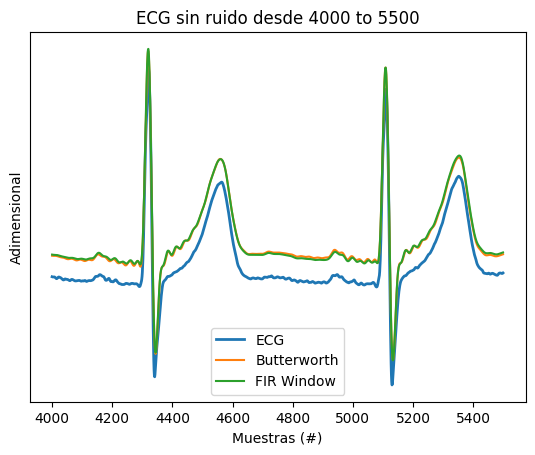

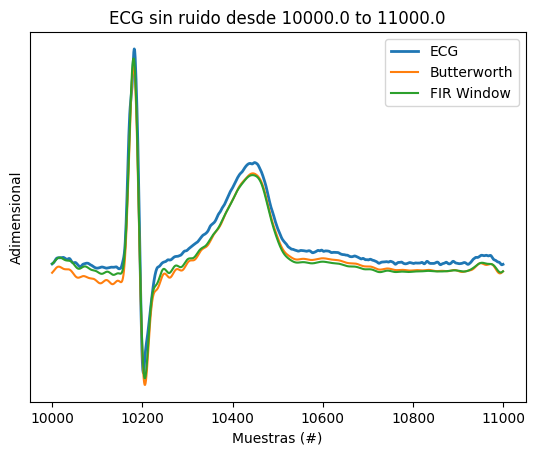

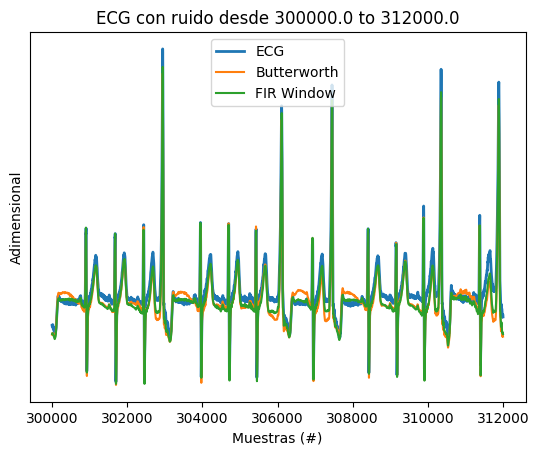

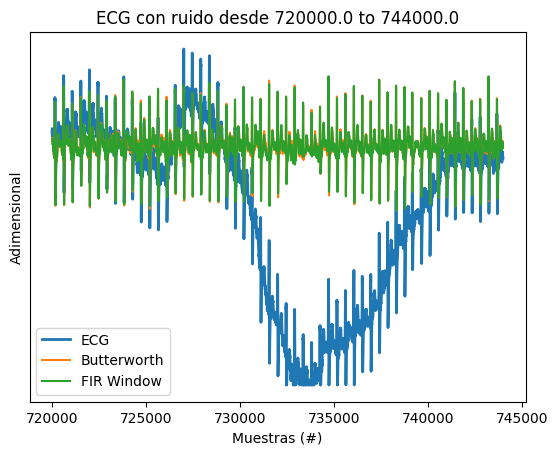

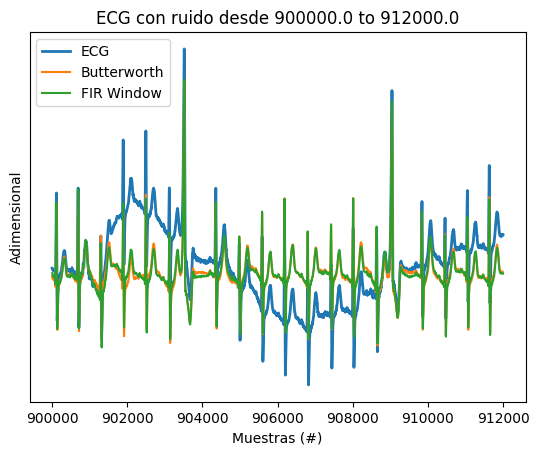

In [3]:
##################
# Lectura de ECG #
##################
print("Cargando señal ECG...")
mat_struct = sio.loadmat('./ECG_TP4.mat')
ecg_one_lead = mat_struct['ecg_lead'].flatten()
N = len(ecg_one_lead)

# Aplicar filtros al ECG (IIR con filtfilt para fase cero)
ecg_filt_butter = signal.sosfiltfilt(sos_butter, ecg_one_lead)
ecg_filt_cauer = signal.sosfiltfilt(sos_cauer, ecg_one_lead)

# FIR con filtfilt para fase lineal (sin retardo)
ecg_filt_fir_vent = signal.filtfilt(b=fir_vent, a=1, x=ecg_one_lead)
ecg_filt_fir_ls = signal.filtfilt(b=fir_ls, a=1, x=ecg_one_lead)

# Filtros IIR
w_butter, h_butter = signal.sosfreqz(sos_butter, worN=2000, fs=fs)
w_cauer, h_cauer = signal.sosfreqz(sos_cauer, worN=2000, fs=fs)


##################
## ECG sin ruido
##################

#################################
# Regiones de interés sin ruido #
#################################

cant_muestras = len(ecg_one_lead)

regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ecg_filt_butter[zoom_region], label='Butterworth')
    plt.plot(zoom_region, ecg_filt_fir_vent[zoom_region], label='FIR Window')
   
    plt.title('ECG sin ruido desde ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()
 
#################################
# Regiones de interés con ruido #
#################################
 
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ecg_filt_butter[zoom_region], label='Butterworth')
    plt.plot(zoom_region, ecg_filt_fir_vent[zoom_region], label='FIR Window')
   
    plt.title('ECG con ruido desde ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()


En los gráficos se puede observar cómo, en las regiones seleccionadas sin presencia aparente de ruido se puede verificar la condición de inocuidad ya que en estos tramos los filtros no producen distorsión significativa de la estructura del ECG, manteniendo sin alteraciones las ondas P, Q, R, S y T. En contraste, las ventanas temporales contaminadas con interferencias muestran la acción efectiva de los filtros, especialmente en los casos de ruido de baja o alta frecuencia. En estos puntos se observa la atenuación marcada de las componentes indeseadas, preservando las características temporales y amplitud relativa del complejo Q, R, S. Esto confirma que los filtros diseñados respetan la plantilla de especificación empleada durante el diseño y resultan adecuados para el procesamiento del registro en condiciones reales, cumpliendo simultáneamente con la supresión de interferencias y con la conservación de los segmentos fisiológicos del ECG.


### CONCLUSIÓN
En este trabajo se diseñaron y compararon filtros digitales FIR e IIR para el procesamiento de un ECG obtenido durante una prueba de esfuerzo. A partir del análisis espectral del latido promedio y de las características fisiológicas del ECG, se definió una plantilla adecuada que preserva las componentes útiles entre 1 y 35.5 Hz y atenúa las interferencias presentes por debajo de 0.1 Hz y por encima de 40 Hz.

Los filtros IIR (Butterworth y Cauer) cumplieron los requisitos con órdenes reducidos, mientras que los FIR (ventana y mínimos cuadrados) lograron fase lineal a costa de un mayor número de coeficientes. La comparación evidenció el compromiso clásico entre selectividad y linealidad de fase.

La aplicación sobre la señal real mostró que todos los filtros eliminan eficazmente el ruido de baja y alta frecuencia sin distorsionar los tramos limpios del ECG, verificando tanto la atenuación requerida como la condición de inocuidad. En conjunto, los resultados confirman que los filtros diseñados son adecuados para mejorar la calidad del registro y preservar la información clínica relevante del ECG.


### AUTOEVALUACIÓN DEL APRENDIZAJE
Para llevar a cabo la tarea semanal nos juntamos y trabajamos juntas. Usamos inteligencia artificial para emprolijar el código y para poder organizar los gráficos. 


### BIBLIOGRAFÍA
Holton, T. (2021). *Digital Signal Processing: Principles and Applications*. Cambridge University Press.
